In [14]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.spatial import distance_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sns.set_theme(style="whitegrid")
%matplotlib inline

In [15]:
def weighted_mean_cov(X, w):
    """Compute weighted mean and covariance matrix in manifold space."""
    w = np.clip(w, 0, None)
    s = w.sum() + 1e-12
    m = (X * w[:, None]).sum(0) / s
    diff = (X - m) * np.sqrt(w[:, None])
    C = (diff.T @ diff) / s + 1e-6 * np.eye(X.shape[1])
    return m, C

def gaussian_pdf(X, mean, cov):
    """Evaluate multivariate Gaussian density."""
    inv, det = np.linalg.inv(cov), np.linalg.det(cov)
    diff = X - mean
    norm = 1.0 / np.sqrt(((2 * np.pi) ** X.shape[1]) * det)
    ex = np.einsum("ni,ij,nj->n", diff, inv, diff)
    return norm * np.exp(-0.5 * ex)

def build_prior(U, W):
    """Geometry-aware prior mapping from manifold coordinates to experts."""
    comps = []
    for j in range(W.shape[1]):
        wj = W[:, j]
        if np.allclose(wj.sum(), 0):
            m, C = U.mean(0), np.cov(U.T) + 1e-6 * np.eye(U.shape[1])
        else:
            m, C = weighted_mean_cov(U, wj)
        comps.append((m, C))

    def prior(U2):
        D = np.zeros((U2.shape[0], W.shape[1]))
        for j, (m, C) in enumerate(comps):
            D[:, j] = gaussian_pdf(U2, m, C)
        D += 1e-12
        return D / D.sum(1, keepdims=True)

    return prior

def corr_r2_scores(U_true, U_pred, eps=1e-12):
    """Variance-weighted global R^2 and dimension-specific correlation scores."""
    U_true = np.asarray(U_true)
    U_pred = np.asarray(U_pred)
    D = U_true.shape[1]
    r_dims, r2_dims = [], []
    for d in range(D):
        x, y = U_true[:, d], U_pred[:, d]
        sx, sy = x.std(), y.std()
        if sx < eps or sy < eps:
            r = 0.0
        else:
            r = np.corrcoef(x, y)[0, 1]
            r = 0.0 if np.isnan(r) else r
        r_dims.append(float(r))
        r2_dims.append(float(r**2))
    vars_ = U_true.var(axis=0)
    w = vars_ / (vars_.sum() + eps)
    r2_global = float((w * np.array(r2_dims)).sum())
    return r2_global, r2_dims, r_dims

def compute_structure_index_simple(data, label, n_bins=8, k=10, num_shuffles=20):
    """
    Computes Structure Index (SI) of continuous weights/covariates on manifold data.
    Measures neighborhood overlap across partitioned value bins.
    """
    data = np.asarray(data)
    label = np.asarray(label).flatten()
    
    bins = np.linspace(np.percentile(label, 2), np.percentile(label, 98), n_bins + 1)
    bin_labels = np.digitize(label, bins) - 1
    valid_mask = (bin_labels >= 0) & (bin_labels < n_bins)
    
    data = data[valid_mask]
    bin_labels = bin_labels[valid_mask]
    unique_bins = np.unique(bin_labels)
    num_valid_bins = len(unique_bins)
    
    if num_valid_bins <= 1:
        return 0.0, np.zeros(num_shuffles)

    def compute_overlap(pts, labels):
        D = distance_matrix(pts, pts)
        np.fill_diagonal(D, np.inf)
        overlap_mat = np.zeros((num_valid_bins, num_valid_bins))
        
        for i, b1 in enumerate(unique_bins):
            idx_b1 = np.where(labels == b1)[0]
            if len(idx_b1) == 0:
                continue
            for j, b2 in enumerate(unique_bins):
                if i == j:
                    continue
                idx_b2 = np.where(labels == b2)[0]
                if len(idx_b2) == 0:
                    continue
                sub_D = D[idx_b1]
                knn_indices = np.argsort(sub_D, axis=1)[:, :k]
                frac = np.mean(np.isin(knn_indices, idx_b2))
                overlap_mat[i, j] = frac
                
        degree = np.sum(overlap_mat, axis=1)
        si = 1.0 - np.mean(degree) / (num_valid_bins - 1 + 1e-12)
        return float(np.clip(2 * (si - 0.5), 0, 1))

    actual_si = compute_overlap(data, bin_labels)
    
    shuf_si = []
    shuf_labels = bin_labels.copy()
    for _ in range(num_shuffles):
        np.random.shuffle(shuf_labels)
        shuf_si.append(compute_overlap(data, shuf_labels))
        
    return actual_si, np.array(shuf_si)

In [16]:
class ExpertLinearProj(nn.Module):
    def __init__(self, in_dim=1, out_dim=4, hidden=11):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden, bias=True),
            nn.ReLU(),
            nn.Linear(hidden, out_dim, bias=True),
        )

    def forward(self, x):
        return self.net(x)

class GatedMoE(nn.Module):
    def __init__(self, n_experts=11, out_dim=4, hidden=11):
        super().__init__()
        self.n_experts = n_experts
        self.experts = nn.ModuleList([
            ExpertLinearProj(1, out_dim, hidden=hidden) for _ in range(n_experts)
        ])

    def forward(self, x, gates):
        # x: [B, n_experts], gates: [B, n_experts]
        outs = [exp(x[:, j:j+1]) for j, exp in enumerate(self.experts)]
        outs = torch.stack(outs, dim=2)  # [B, out_dim, n_experts]
        return (outs * gates.unsqueeze(1)).sum(2)

In [ ]:
#### ALTERNATIVE CELL ¤###########################

# ==========================================================
# Cell 4: Biologically Inspired Noisy Data Generation
# ==========================================================
# Cell-type definitions (can be modified to arbitrary length)
FULL_FEATS = [
    "DeepPyr", "DeepPV", "DeepBist", "SupPyr", "SupPV", "SupBist",
    "DeepCCK", "DeepAxoAxonic", "SupCCK", "SupAxoAxonic", "OriensInt"
]

N_EXPERTS = len(FULL_FEATS)
N_SAMPLES = 1000
LATENT_DIM = 4

# 1. Complex 2D nonlinear surface embedded in 4D with substantial noise
u_coord = np.random.uniform(-np.pi, np.pi, N_SAMPLES)
v_coord = np.random.uniform(-np.pi, np.pi, N_SAMPLES)

U_true = np.zeros((N_SAMPLES, LATENT_DIM))
# Nonlinear embedding coordinates
U_true[:, 0] = np.sin(u_coord) + 0.4 * np.sin(v_coord)
U_true[:, 1] = np.cos(u_coord) + 0.4 * np.cos(2 * v_coord)
U_true[:, 2] = 0.5 * np.sin(u_coord + v_coord)
U_true[:, 3] = 0.5 * np.cos(u_coord - v_coord)

# Inject heavy isotropic jitter so the manifold is diffuse rather than a crisp curve
MANIFOLD_NOISE_STD = 0.35
U_true += np.random.normal(0, MANIFOLD_NOISE_STD, size=U_true.shape)

# 2. Activity / Weight Generation
# Start with background Poisson-like baseline noise across all cells
X_raw = np.random.gamma(shape=1.5, scale=0.6, size=(N_SAMPLES, N_EXPERTS))

# Identify Pyramidal and Interneuron indices
pyr_indices = [i for i, name in enumerate(FULL_FEATS) if "Pyr" in name]
non_pyr_indices = [i for i in range(N_EXPERTS) if i not in pyr_indices]

# A) Pyramidal Cells: Broad, ubiquitous coverage across the entire manifold
#    High baseline, broad global modulation, large intrinsic noise
for idx in pyr_indices:
    # Weak, global linear drift across the manifold + high diffuse drive
    diffuse_drive = 2.0 + 0.3 * U_true[:, 0] + 0.2 * U_true[:, 1]
    poisson_fluctuation = np.random.exponential(scale=0.8, size=N_SAMPLES)
    X_raw[:, idx] += diffuse_drive + poisson_fluctuation

# B) Interneurons: Highly selective, localized receptive fields (Gaussian tuning)
#    Each interneuron type fires strongly only in a localized patch of (U0, U1)
for k, idx in enumerate(non_pyr_indices):
    # Anchor centers distributed irregularly over latent space
    center_angle = 2 * np.pi * k / len(non_pyr_indices)
    center_r = 0.8
    c_x = center_r * np.cos(center_angle)
    c_y = center_r * np.sin(center_angle)
    
    # Distance from receptive field center
    dist_sq = (U_true[:, 0] - c_x)**2 + (U_true[:, 1] - c_y)**2
    spatial_width = 0.45  # Small width = tight spatial selectivity
    
    selective_drive = 4.0 * np.exp(-dist_sq / (2 * spatial_width**2))
    # Sparse dropout/silence outside the receptive field
    selective_drive[dist_sq > (2.5 * spatial_width**2)] *= 0.1
    
    X_raw[:, idx] += selective_drive

# 3. Behavioral covariate (e.g. ripple frequency) with its own measurement noise
covariate_freq = 150.0 + 25.0 * U_true[:, 0] - 15.0 * U_true[:, 1] + np.random.normal(0, 8.0, N_SAMPLES)

# 4. Uniform Random Train/Test Split
indices = np.arange(N_SAMPLES)
train_idx, test_idx = train_test_split(indices, test_size=0.25, random_state=SEED)

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
U_train_raw, U_test_raw = U_true[train_idx], U_true[test_idx]
cov_test = covariate_freq[test_idx]

print(f"Noisy Dataset Generated: N={N_SAMPLES}, Experts={N_EXPERTS}")
print(f"  Pyramidal types (ubiquitous): {[FULL_FEATS[i] for i in pyr_indices]}")
print(f"  Interneuron types (selective): {[FULL_FEATS[i] for i in non_pyr_indices]}")

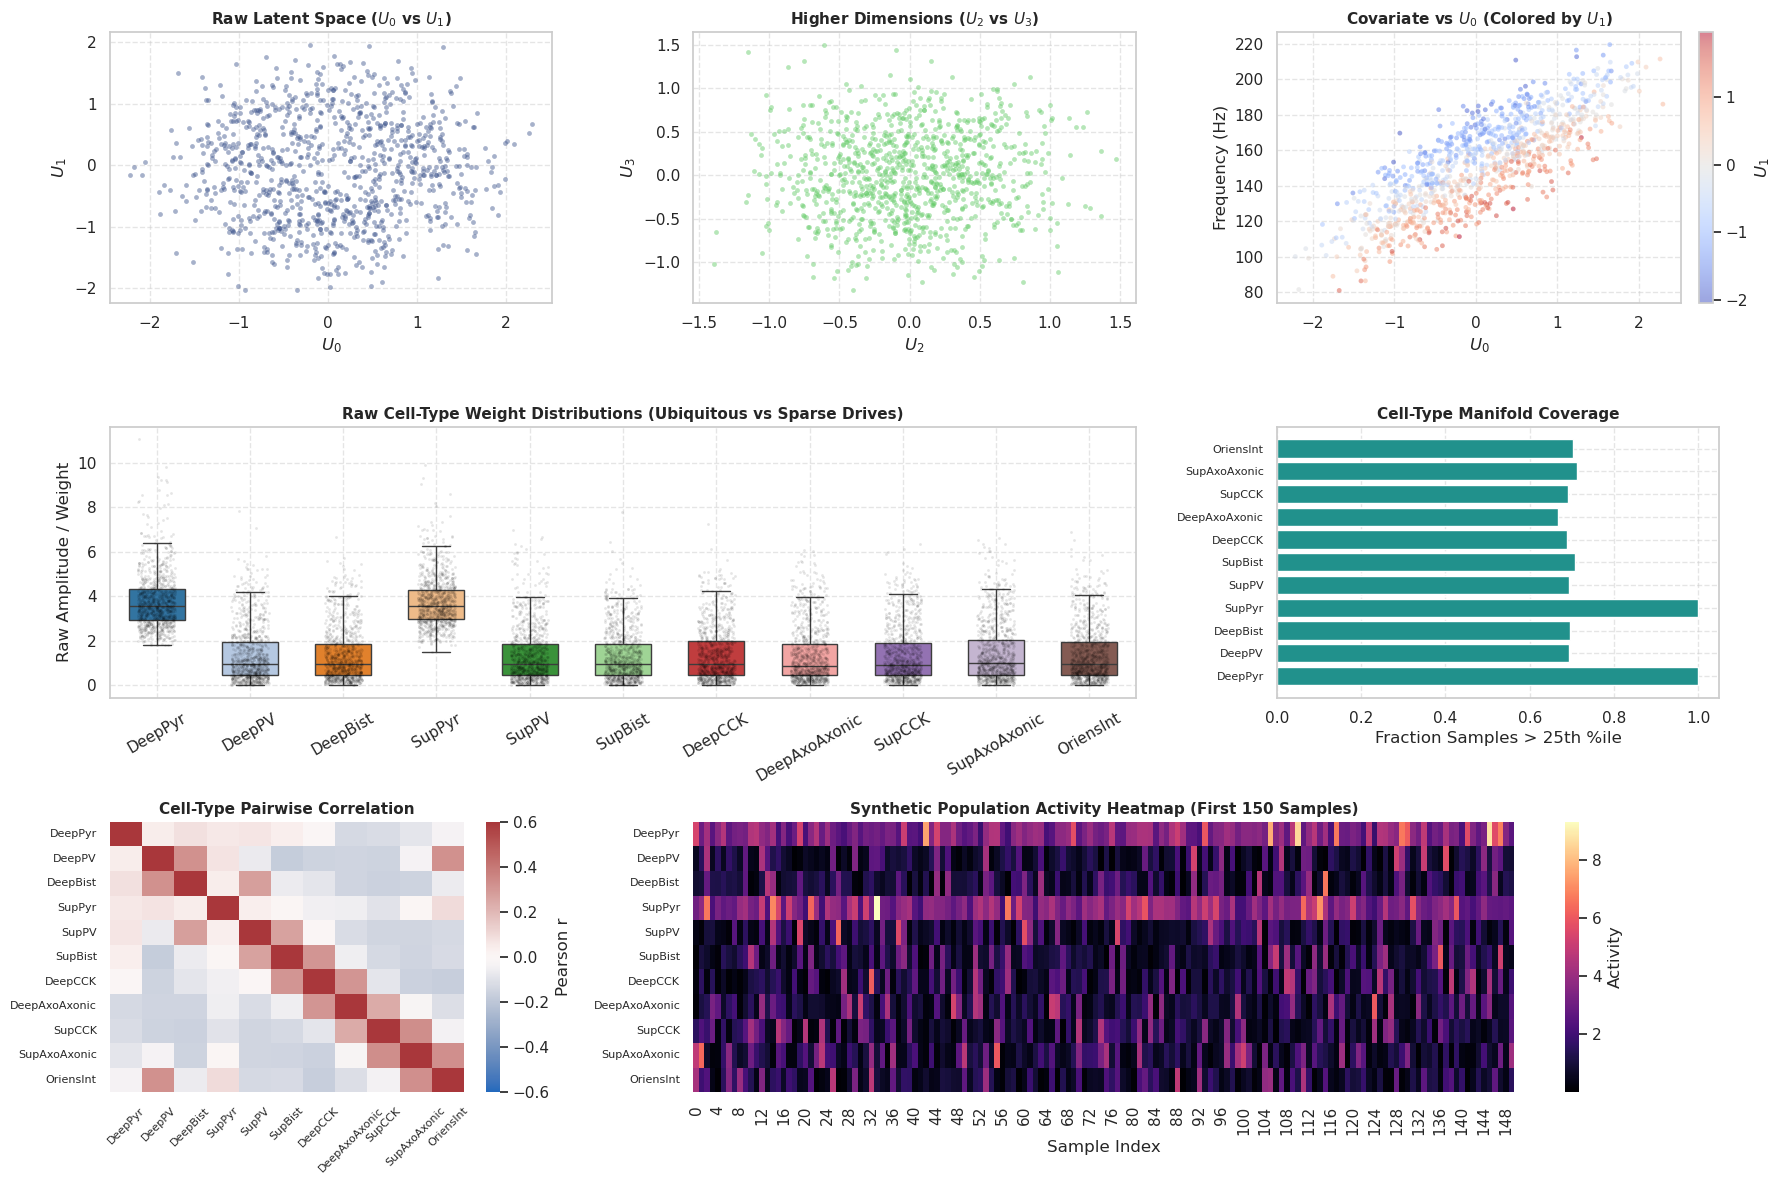

In [36]:
# ==========================================================
# Raw Dataset Exploratory Data Analysis (EDA)
# ==========================================================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1])

# ----------------------------------------------------------
# 1. Raw Latent Geometry Projections (Without Feature Colors)
# ----------------------------------------------------------
# 1a. U0 vs U1 (Primary 2D manifold projection)
ax_u01 = fig.add_subplot(gs[0, 0])
ax_u01.scatter(U_true[:, 0], U_true[:, 1], c="#3b528b", s=12, alpha=0.45, linewidths=0)
ax_u01.set_title("Raw Latent Space ($U_0$ vs $U_1$)", fontsize=11, fontweight="bold")
ax_u01.set_xlabel("$U_0$")
ax_u01.set_ylabel("$U_1$")
ax_u01.grid(True, linestyle="--", alpha=0.5)

# 1b. U2 vs U3 (Higher-dimensional manifold projection)
ax_u23 = fig.add_subplot(gs[0, 1])
ax_u23.scatter(U_true[:, 2], U_true[:, 3], c="#5ec962", s=12, alpha=0.45, linewidths=0)
ax_u23.set_title("Higher Dimensions ($U_2$ vs $U_3$)", fontsize=11, fontweight="bold")
ax_u23.set_xlabel("$U_2$")
ax_u23.set_ylabel("$U_3$")
ax_u23.grid(True, linestyle="--", alpha=0.5)

# 1c. Behavioral Covariate vs Latent Dimension
ax_cov = fig.add_subplot(gs[0, 2])
sc_cov = ax_cov.scatter(U_true[:, 0], covariate_freq, c=U_true[:, 1], cmap="coolwarm", s=12, alpha=0.5, linewidths=0)
ax_cov.set_title("Covariate vs $U_0$ (Colored by $U_1$)", fontsize=11, fontweight="bold")
ax_cov.set_xlabel("$U_0$")
ax_cov.set_ylabel("Frequency (Hz)")
cbar_cov = fig.colorbar(sc_cov, ax=ax_cov, fraction=0.046, pad=0.04)
cbar_cov.set_label("$U_1$")
ax_cov.grid(True, linestyle="--", alpha=0.5)

# ----------------------------------------------------------
# 2. Raw Activity Distributions & Population Sparsity
# ----------------------------------------------------------
# 2a. Violin / Box plot of raw firing rates / weights per cell type
ax_dist = fig.add_subplot(gs[1, :2])
df_raw_x = pd.DataFrame(X_raw, columns=FULL_FEATS)
sns.boxplot(data=df_raw_x, orient="v", ax=ax_dist, palette="tab20", showfliers=False, width=0.6)
sns.stripplot(data=df_raw_x, orient="v", ax=ax_dist, color="black", alpha=0.1, size=2, jitter=0.2)
ax_dist.set_title("Raw Cell-Type Weight Distributions (Ubiquitous vs Sparse Drives)", fontsize=11, fontweight="bold")
ax_dist.set_ylabel("Raw Amplitude / Weight")
ax_dist.tick_params(axis="x", rotation=30)
ax_dist.grid(True, linestyle="--", alpha=0.5)

# 2b. Fraction of active samples per cell type (Sparsity check)
ax_sparse = fig.add_subplot(gs[1, 2])
threshold = np.percentile(X_raw, 25) # baseline threshold
active_fraction = (X_raw > threshold).mean(axis=0)
bars = ax_sparse.barh(range(N_EXPERTS), active_fraction, color="#21918c", align="center")
ax_sparse.set_yticks(range(N_EXPERTS))
ax_sparse.set_yticklabels(FULL_FEATS, fontsize=8)
ax_sparse.set_xlabel("Fraction Samples > 25th %ile")
ax_sparse.set_title("Cell-Type Manifold Coverage", fontsize=11, fontweight="bold")
ax_sparse.set_xlim(0, 1.05)
ax_sparse.grid(True, linestyle="--", alpha=0.5)

# ----------------------------------------------------------
# 3. Population Dynamics: Correlation & Synthetic Raster
# ----------------------------------------------------------
# 3a. Cross-cell correlation matrix (Co-tuning / Module structure)
ax_corr = fig.add_subplot(gs[2, 0])
corr_matrix = np.corrcoef(X_raw.T)
sns.heatmap(
    corr_matrix, 
    xticklabels=FULL_FEATS, 
    yticklabels=FULL_FEATS, 
    cmap="vlag", 
    center=0, 
    vmin=-0.6, 
    vmax=0.6, 
    ax=ax_corr, 
    cbar_kws={"label": "Pearson r"}
)
ax_corr.set_title("Cell-Type Pairwise Correlation", fontsize=11, fontweight="bold")
ax_corr.tick_params(axis="x", rotation=45, labelsize=8)
ax_corr.tick_params(axis="y", labelsize=8)

# 3b. Synthetic Activity Raster (Heatmap over 150 consecutive samples)
ax_rast = fig.add_subplot(gs[2, 1:])
n_display = min(150, N_SAMPLES)
sns.heatmap(
    X_raw[:n_display, :].T, 
    cmap="magma", 
    ax=ax_rast, 
    cbar_kws={"label": "Activity"}
)
ax_rast.set_yticks(np.arange(N_EXPERTS) + 0.5)
ax_rast.set_yticklabels(FULL_FEATS, rotation=0, fontsize=8)
ax_rast.set_xlabel("Sample Index")
ax_rast.set_title(f"Synthetic Population Activity Heatmap (First {n_display} Samples)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

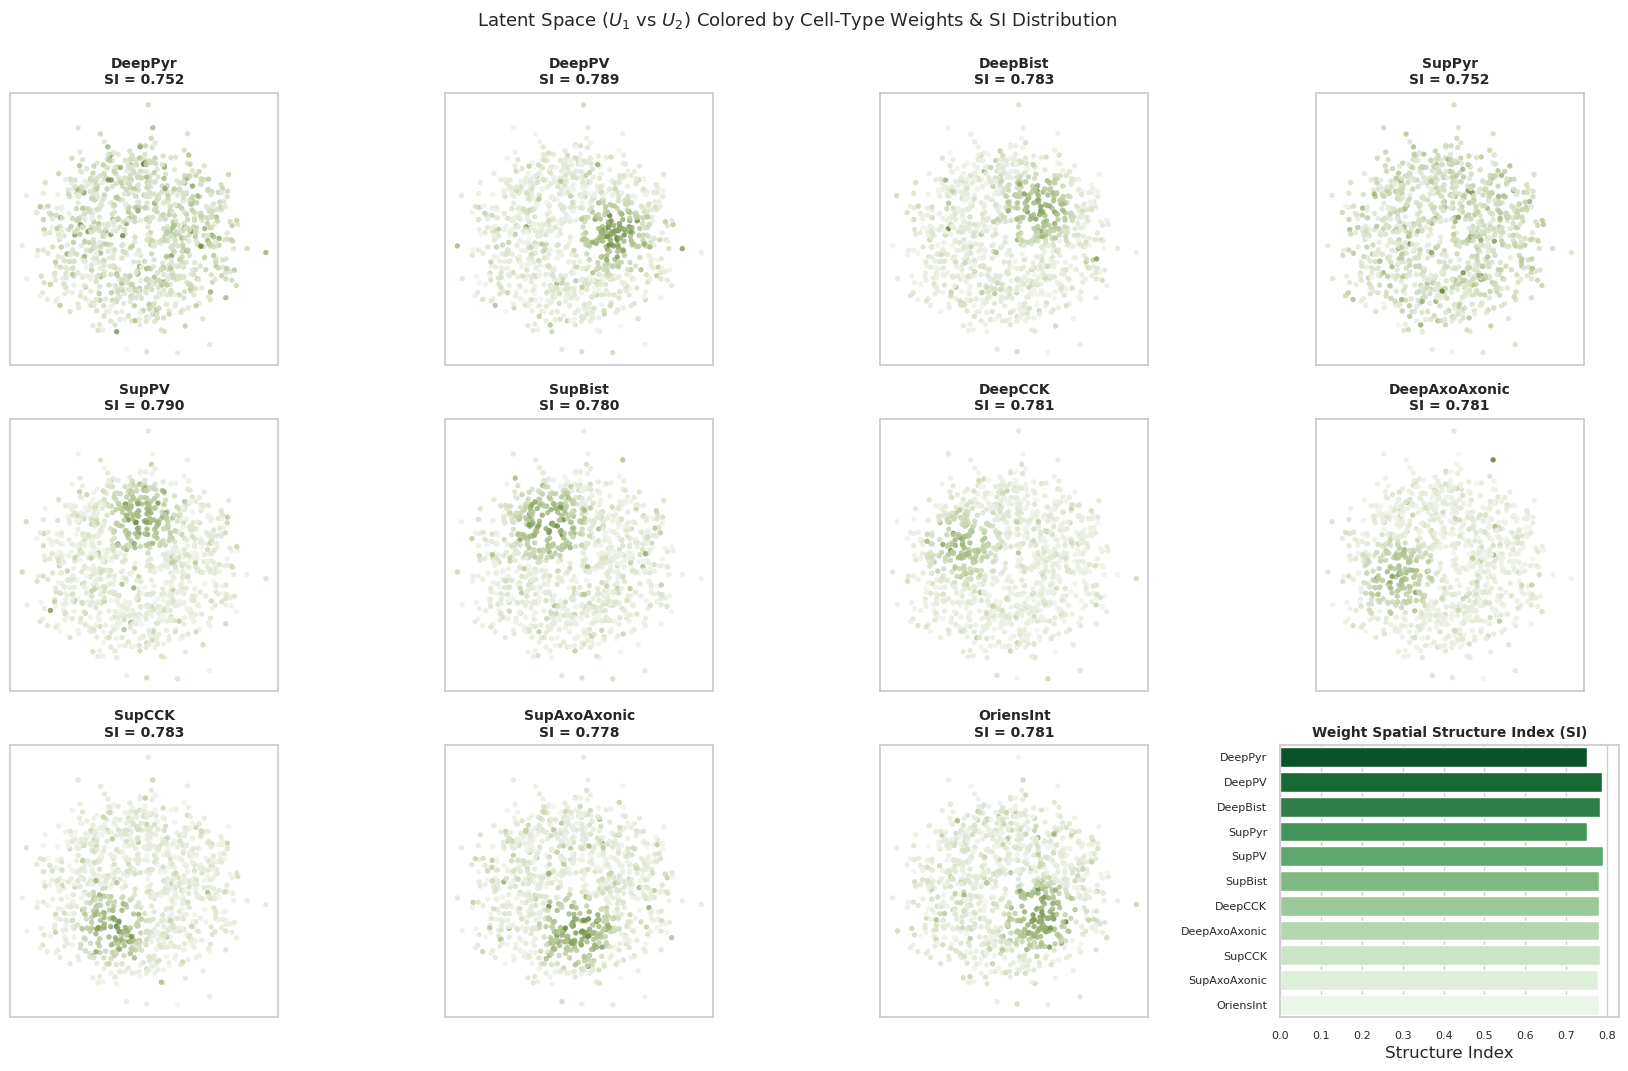

In [28]:
# 1. Compute Structure Index (SI) of each cell-type's input weight on the 2D latent space
si_weights_records = []
for i, feat_name in enumerate(FULL_FEATS):
    si_val, shuf_null = compute_structure_index_simple(
        U_true[:, :2], 
        X_raw[:, i], 
        n_bins=8, 
        k=10, 
        num_shuffles=25
    )
    si_weights_records.append({
        "cell_type": feat_name,
        "SI": si_val,
        "shuf_95": np.percentile(shuf_null, 95)
    })

df_si_weights = pd.DataFrame(si_weights_records)

# 2. Plotting: Generic grid layout adapting to arbitrary N_EXPERTS
custom_green = LinearSegmentedColormap.from_list(
    "custom_green_ramp",
    ["#f1f4ec", "#d6e0c4", "#b5c796", "#86a25f", "#5f7f34"],
    N=256
)

n_cols = 4
# Extra slot reserved for the SI barplot summary
n_panels = N_EXPERTS + 1
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows))
axes = axes.ravel()

for i, feat_name in enumerate(FULL_FEATS):
    ax = axes[i]
    w = X_raw[:, i]
    si_score = df_si_weights.loc[df_si_weights["cell_type"] == feat_name, "SI"].values[0]
    
    sc = ax.scatter(
        U_true[:, 0],
        U_true[:, 1],
        c=w,
        cmap=custom_green,
        s=15,
        alpha=0.85,
        linewidths=0
    )
    ax.set_title(f"{feat_name}\nSI = {si_score:.3f}", fontsize=10, fontweight="bold")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

# Bar plot panel: Structure Index per cell-type weight
ax_bar = axes[N_EXPERTS]
sns.barplot(
    data=df_si_weights,
    x="SI",
    y="cell_type",
    hue="cell_type",
    palette="Greens_r",
    legend=False,
    ax=ax_bar
)
ax_bar.set_title("Weight Spatial Structure Index (SI)", fontsize=10, fontweight="bold")
ax_bar.set_xlabel("Structure Index")
ax_bar.set_ylabel("")
ax_bar.tick_params(labelsize=8)

# Turn off unused subplot axes
for j in range(n_panels, len(axes)):
    axes[j].axis("off")

fig.suptitle("Latent Space ($U_1$ vs $U_2$) Colored by Cell-Type Weights & SI Distribution", fontsize=13, y=0.99)
plt.tight_layout()
plt.show()

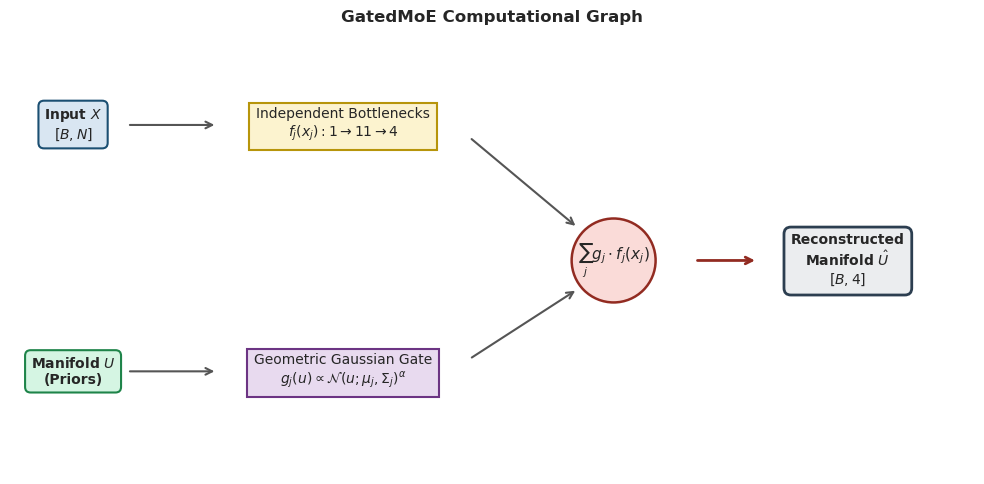

In [40]:
import matplotlib.pyplot as plt

# Create standalone figure
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

# Input & Prior nodes
ax.text(
    0.02,
    0.85,
    "Input $X$\n$[B, N]$",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.4", fc="#d9e6f2", ec="#1b4f72", lw=1.5),
    fontsize=10,
    fontweight="bold",
)
ax.text(
    0.02,
    0.25,
    "Manifold $U$\n(Priors)",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.4", fc="#d5f5e3", ec="#1e8449", lw=1.5),
    fontsize=10,
    fontweight="bold",
)

# Connect to processing blocks
ax.annotate(
    "",
    xy=(0.18, 0.85),
    xytext=(0.08, 0.85),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"),
)
ax.annotate(
    "",
    xy=(0.18, 0.25),
    xytext=(0.08, 0.25),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"),
)

# Experts and Gating functions[cite: 1, 2]
ax.text(
    0.32,
    0.85,
    "Independent Bottlenecks\n" + r"$f_j(x_j): 1 \to 11 \to 4$",
    ha="center",
    va="center",
    bbox=dict(boxstyle="square,pad=0.5", fc="#fcf3cf", ec="#b7950b", lw=1.5),
    fontsize=10,
)
ax.text(
    0.32,
    0.25,
    "Geometric Gaussian Gate\n"
    + r"$g_j(u) \propto \mathcal{N}(u; \mu_j, \Sigma_j)^\alpha$",
    ha="center",
    va="center",
    bbox=dict(boxstyle="square,pad=0.5", fc="#e8daef", ec="#6c3483", lw=1.5),
    fontsize=10,
)

# Connect to mixture node
ax.annotate(
    "",
    xy=(0.58, 0.60),
    xytext=(0.46, 0.82),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"),
)
ax.annotate(
    "",
    xy=(0.58, 0.45),
    xytext=(0.46, 0.28),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"),
)

# Gated mixture node[cite: 1, 2]
ax.text(
    0.62,
    0.52,
    r"$\sum_j g_j \cdot f_j(x_j)$",
    ha="center",
    va="center",
    bbox=dict(boxstyle="circle,pad=0.4", fc="#fadbd8", ec="#922b21", lw=1.8),
    fontsize=11,
    fontweight="bold",
)

# Connect to final output
ax.annotate(
    "",
    xy=(0.78, 0.52),
    xytext=(0.71, 0.52),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="#922b21"),
)
ax.text(
    0.88,
    0.52,
    "Reconstructed\nManifold $\hat{U}$\n$[B, 4]$",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.5", fc="#ebedef", ec="#2c3e50", lw=2),
    fontsize=10,
    fontweight="bold",
)

# Formatting
ax.set_xlim(-0.05, 1.02)
ax.set_ylim(0.0, 1.05)
ax.set_title("GatedMoE Computational Graph", fontsize=12, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

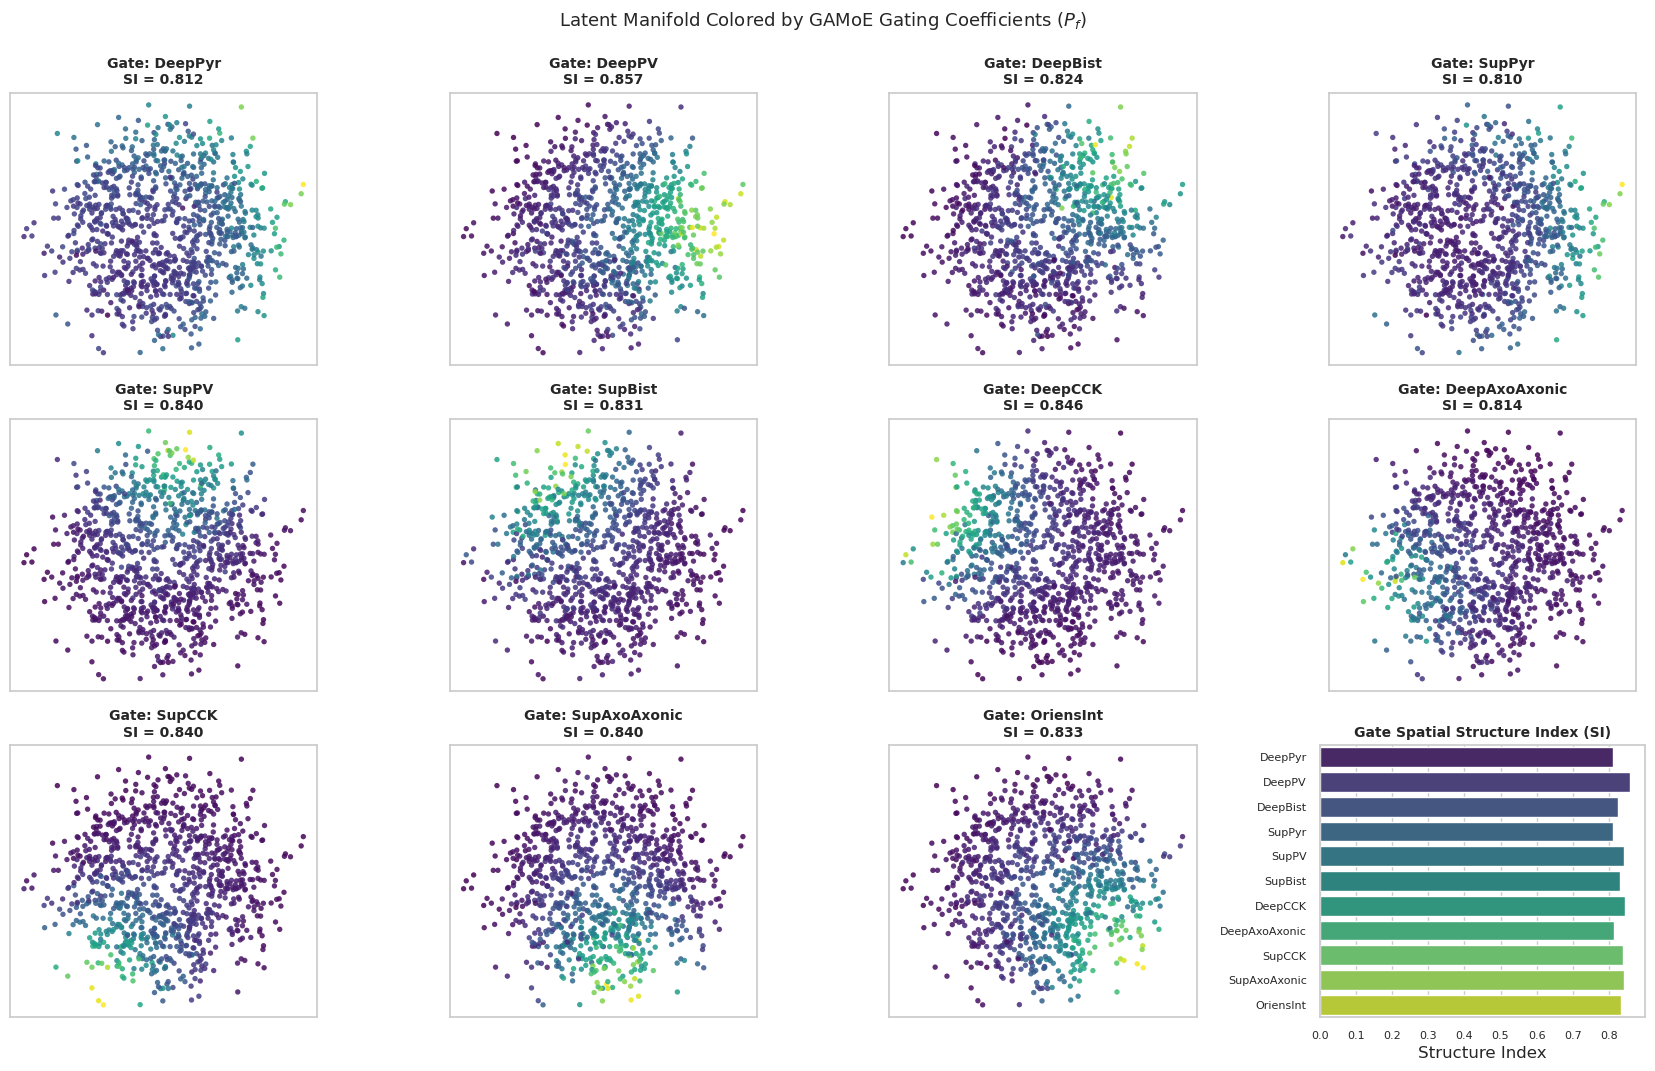

In [38]:
# 1. Fit manifold Gaussian prior and generate normalized gating weights
prior_fn = build_prior(U_train_raw, X_train_raw)
Q_train = prior_fn(U_train_raw)
Q_test  = prior_fn(U_test_raw)
Q_all   = prior_fn(U_true)

ALPHA_FUSION = 2.0
Pf_all = Q_all ** ALPHA_FUSION
Pf_all = Pf_all / (Pf_all.sum(1, keepdims=True) + 1e-12)

# 2. Compute SI for the resulting geometric gates
si_gate_records = []
for i, feat_name in enumerate(FULL_FEATS):
    si_val, _ = compute_structure_index_simple(
        U_true[:, :2], 
        Pf_all[:, i], 
        n_bins=8, 
        k=10, 
        num_shuffles=0
    )
    si_gate_records.append({"cell_type": feat_name, "SI_gate": si_val})

df_si_gates = pd.DataFrame(si_gate_records)

# 3. Plotting: Manifold colored by the computed gate probabilities
n_panels_gate = N_EXPERTS + 1
n_rows_gate = math.ceil(n_panels_gate / n_cols)

fig, axes = plt.subplots(n_rows_gate, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows_gate))
axes = axes.ravel()

for i, feat_name in enumerate(FULL_FEATS):
    ax = axes[i]
    gate_prob = Pf_all[:, i]
    si_g = df_si_gates.loc[df_si_gates["cell_type"] == feat_name, "SI_gate"].values[0]
    
    sc = ax.scatter(
        U_true[:, 0],
        U_true[:, 1],
        c=gate_prob,
        cmap="viridis",
        s=15,
        alpha=0.85,
        linewidths=0
    )
    ax.set_title(f"Gate: {feat_name}\nSI = {si_g:.3f}", fontsize=10, fontweight="bold")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

# Bar plot panel: Gate probabilities spatial coherence
ax_bar_gate = axes[N_EXPERTS]
sns.barplot(
    data=df_si_gates,
    x="SI_gate",
    y="cell_type",
    hue="cell_type",
    palette="viridis",
    legend=False,
    ax=ax_bar_gate
)
ax_bar_gate.set_title("Gate Spatial Structure Index (SI)", fontsize=10, fontweight="bold")
ax_bar_gate.set_xlabel("Structure Index")
ax_bar_gate.set_ylabel("")
ax_bar_gate.tick_params(labelsize=8)

for j in range(n_panels_gate, len(axes)):
    axes[j].axis("off")

fig.suptitle("Latent Manifold Colored by GAMoE Gating Coefficients ($P_{f}$)", fontsize=13, y=0.99)
plt.tight_layout()
plt.show()

In [39]:
# 1. Fuse training and testing gates
Pf_tr = Q_train ** ALPHA_FUSION
Pf_tr = Pf_tr / (Pf_tr.sum(1, keepdims=True) + 1e-12)

Pf_te = Q_test ** ALPHA_FUSION
Pf_te = Pf_te / (Pf_te.sum(1, keepdims=True) + 1e-12)

# 2. Standardization
scX = StandardScaler().fit(X_train_raw)
scY = StandardScaler().fit(U_train_raw)

Xt = torch.tensor(scX.transform(X_train_raw), dtype=torch.float32, device=device)
Xv = torch.tensor(scX.transform(X_test_raw), dtype=torch.float32, device=device)
Yt = torch.tensor(scY.transform(U_train_raw), dtype=torch.float32, device=device)
Yv = torch.tensor(scY.transform(U_test_raw), dtype=torch.float32, device=device)

Gtr = torch.tensor(Pf_tr, dtype=torch.float32, device=device)
Gte = torch.tensor(Pf_te, dtype=torch.float32, device=device)

# 3. Model & training setup
model = GatedMoE(n_experts=N_EXPERTS, out_dim=LATENT_DIM, hidden=11).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-4)
criterion = nn.MSELoss()

for epoch in range(120):
    model.train()
    optimizer.zero_grad()
    yhat = model(Xt, Gtr)
    loss = criterion(yhat, Yt)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    val_pred = model(Xv, Gte).cpu().numpy()
    val_pred = scY.inverse_transform(val_pred)

r2_full, r2_dims, _ = corr_r2_scores(U_test_raw, val_pred)
print(f"Full Model Global R²: {r2_full:.4f}")
for d, r2 in enumerate(r2_dims):
    print(f"  Dim {d+1} R²: {r2:.4f}")

Full Model Global R²: 0.7592
  Dim 1 R²: 0.9714
  Dim 2 R²: 0.9475
  Dim 3 R²: 0.2048
  Dim 4 R²: 0.2679


In [31]:
# Dynamic condition builder matching available features in FULL_FEATS
ABLATION_CONDITIONS = {"All": []}

# If pairs exist in the list, ablate by canonical groupings; otherwise, ablate single features
for pair_name, candidates in [("No_Pyr", ["DeepPyr", "SupPyr"]), ("No_PV", ["DeepPV", "SupPV"])]:
    present = [f for f in candidates if f in FULL_FEATS]
    if present:
        ABLATION_CONDITIONS[pair_name] = present

# First half versus second half ablated (modules 1 and 2)
mid = N_EXPERTS // 2
ABLATION_CONDITIONS["No_Module1"] = FULL_FEATS[:mid]
ABLATION_CONDITIONS["No_Module2"] = FULL_FEATS[mid:]

feat_to_idx = {f: i for i, f in enumerate(FULL_FEATS)}
ablation_results = {}
ablation_preds = {}

model.eval()
with torch.no_grad():
    for cond_name, drop_list in ABLATION_CONDITIONS.items():
        mask = torch.ones(N_EXPERTS, dtype=torch.float32, device=device)
        for f in drop_list:
            mask[feat_to_idx[f]] = 0.0
            
        Pf_ablated = Gte * mask.unsqueeze(0)
        Pf_ablated = Pf_ablated / (Pf_ablated.sum(1, keepdim=True) + 1e-12)
        
        Y_pred_scaled = model(Xv, Pf_ablated).cpu().numpy()
        Y_pred = scY.inverse_transform(Y_pred_scaled)
        
        r2_g, _, _ = corr_r2_scores(U_test_raw, Y_pred)
        rmse = math.sqrt(mean_squared_error(U_test_raw, Y_pred))
        
        ablation_results[cond_name] = {"R2": r2_g, "RMSE": rmse}
        ablation_preds[cond_name] = Y_pred

pd.DataFrame(ablation_results).T

,R2,RMSE
All,0.809107,0.320045
No_Pyr,0.777400,0.623224
No_PV,0.740641,0.839373
No_Module1,0.576295,0.797377
No_Module2,0.554946,1.074533


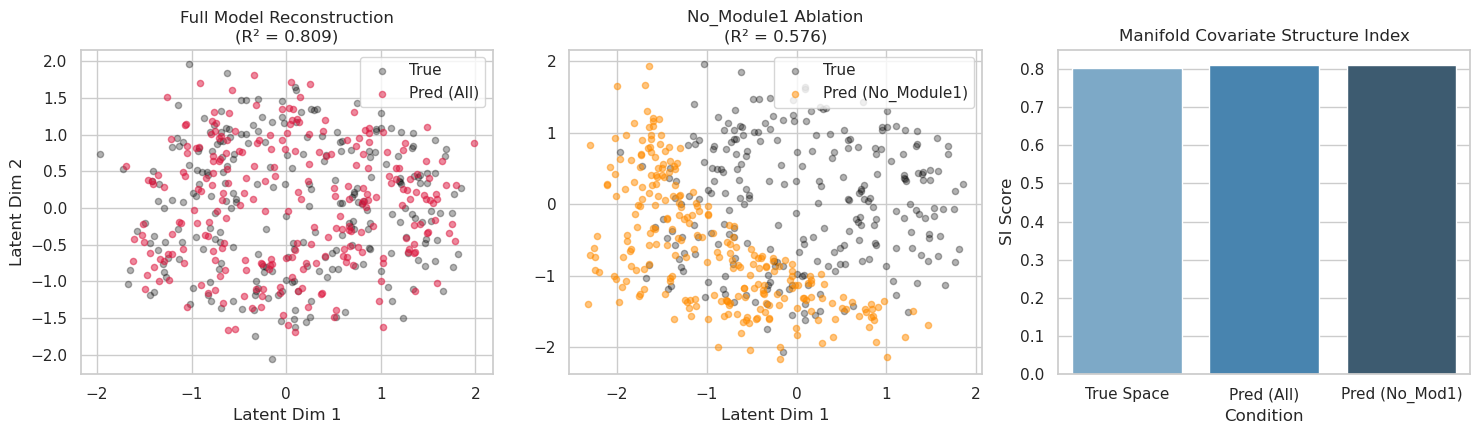

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Overlay: Full Model Test Predictions vs True Space
axes[0].scatter(U_test_raw[:, 0], U_test_raw[:, 1], c="black", alpha=0.3, s=20, label="True")
axes[0].scatter(ablation_preds["All"][:, 0], ablation_preds["All"][:, 1], c="crimson", alpha=0.5, s=20, label="Pred (All)")
axes[0].set_title(f"Full Model Reconstruction\n(R² = {ablation_results['All']['R2']:.3f})")
axes[0].set_xlabel("Latent Dim 1")
axes[0].set_ylabel("Latent Dim 2")
axes[0].legend()

# 2. Overlay: Module 1 Ablated Reconstruction
axes[1].scatter(U_test_raw[:, 0], U_test_raw[:, 1], c="black", alpha=0.3, s=20, label="True")
axes[1].scatter(ablation_preds["No_Module1"][:, 0], ablation_preds["No_Module1"][:, 1], c="darkorange", alpha=0.5, s=20, label="Pred (No_Module1)")
axes[1].set_title(f"No_Module1 Ablation\n(R² = {ablation_results['No_Module1']['R2']:.3f})")
axes[1].set_xlabel("Latent Dim 1")
axes[1].legend()

# 3. Structure Index of Behavioral Covariate (Ripple Freq) across spaces
si_true, _ = compute_structure_index_simple(U_test_raw, cov_test)
si_pred_all, _ = compute_structure_index_simple(ablation_preds["All"], cov_test)
si_pred_mod1, _ = compute_structure_index_simple(ablation_preds["No_Module1"], cov_test)

df_si_eval = pd.DataFrame({
    "Condition": ["True Space", "Pred (All)", "Pred (No_Mod1)"],
    "SI (Ripple Freq)": [si_true, si_pred_all, si_pred_mod1]
})
sns.barplot(
    data=df_si_eval, 
    x="Condition", 
    y="SI (Ripple Freq)", 
    hue="Condition",
    palette="Blues_d", 
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Manifold Covariate Structure Index")
axes[2].set_ylabel("SI Score")

plt.tight_layout()
plt.show()

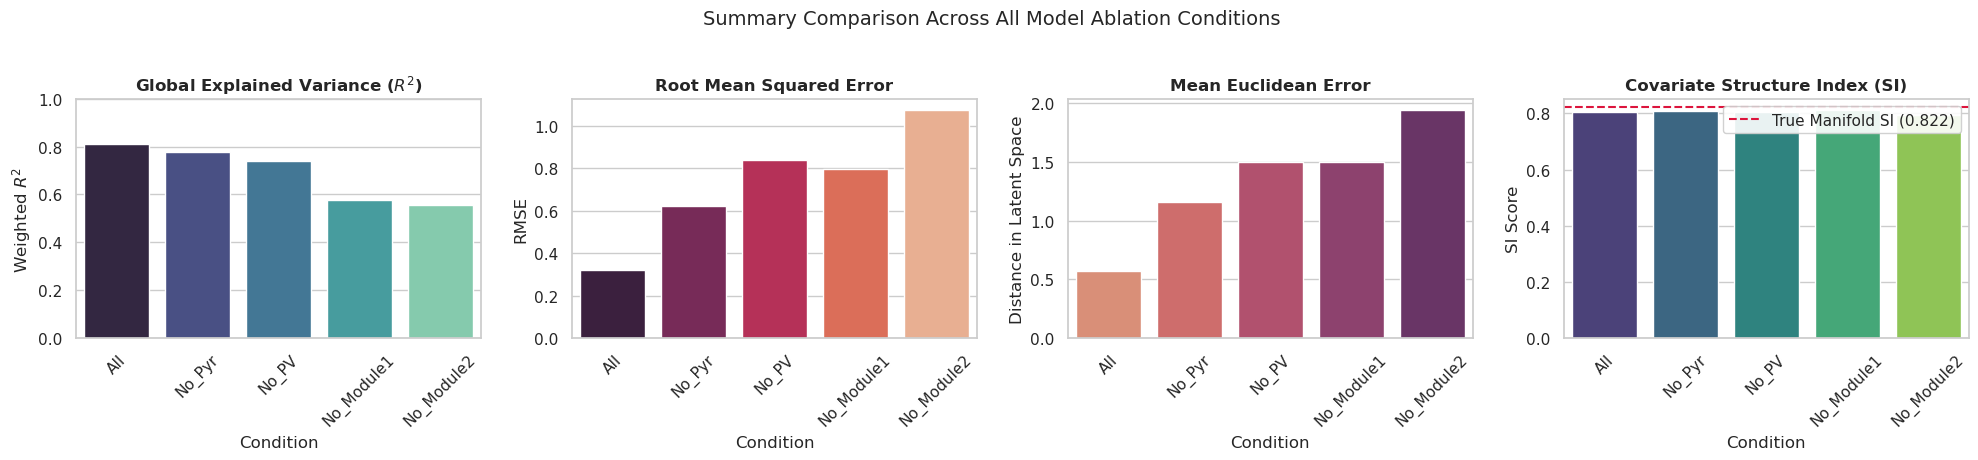

,R2_Global,RMSE,Mean_Euclid_Error,SI_Covariate
Condition,,,,
All,0.8091,0.3200,0.5673,0.8062
No_Pyr,0.7774,0.6232,1.1596,0.8074
No_PV,0.7406,0.8394,1.4990,0.8056
No_Module1,0.5763,0.7974,1.4980,0.8116
No_Module2,0.5549,1.0745,1.9388,0.7934


In [33]:
# ==========================================================
# Comprehensive Ablation Comparison (R², RMSE, Mean Error, SI)
# ==========================================================
records = []

# Evaluate Structure Index of the behavioral covariate on the true latent space
si_true_baseline, _ = compute_structure_index_simple(
    U_test_raw[:, :2], 
    cov_test, 
    n_bins=8, 
    k=10, 
    num_shuffles=0
)

for cond_name, Y_pred in ablation_preds.items():
    # 1. Performance metrics
    r2_val, _, _ = corr_r2_scores(U_test_raw, Y_pred)
    rmse_val = math.sqrt(mean_squared_error(U_test_raw, Y_pred))
    euclid_err = np.linalg.norm(U_test_raw - Y_pred, axis=1).mean()
    
    # 2. Geometric Structure Index on predicted latent coordinates (Dims 1 & 2)
    si_val, _ = compute_structure_index_simple(
        Y_pred[:, :2], 
        cov_test, 
        n_bins=8, 
        k=10, 
        num_shuffles=0
    )
    
    records.append({
        "Condition": cond_name,
        "R2_Global": r2_val,
        "RMSE": rmse_val,
        "Mean_Euclid_Error": euclid_err,
        "SI_Covariate": si_val
    })

df_compare = pd.DataFrame(records)

# ----------------------------------------------------------
# Multi-Panel Benchmark Comparison Plot
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

# 1. R² Global Comparison
sns.barplot(
    data=df_compare, 
    x="Condition", 
    y="R2_Global", 
    hue="Condition",
    palette="mako", 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title("Global Explained Variance ($R^2$)", fontweight="bold")
axes[0].set_ylabel("Weighted $R^2$")
axes[0].set_ylim(0, max(1.0, df_compare["R2_Global"].max() * 1.15))
axes[0].tick_params(axis="x", rotation=45)

# 2. RMSE Comparison
sns.barplot(
    data=df_compare, 
    x="Condition", 
    y="RMSE", 
    hue="Condition",
    palette="rocket", 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title("Root Mean Squared Error", fontweight="bold")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=45)

# 3. Mean Euclidean Error
sns.barplot(
    data=df_compare, 
    x="Condition", 
    y="Mean_Euclid_Error", 
    hue="Condition",
    palette="flare", 
    legend=False, 
    ax=axes[2]
)
axes[2].set_title("Mean Euclidean Error", fontweight="bold")
axes[2].set_ylabel("Distance in Latent Space")
axes[2].tick_params(axis="x", rotation=45)

# 4. Behavioral Covariate Structure Index Comparison
sns.barplot(
    data=df_compare, 
    x="Condition", 
    y="SI_Covariate", 
    hue="Condition",
    palette="viridis", 
    legend=False, 
    ax=axes[3]
)
axes[3].axhline(
    si_true_baseline, 
    color="crimson", 
    linestyle="--", 
    linewidth=1.5, 
    label=f"True Manifold SI ({si_true_baseline:.3f})"
)
axes[3].set_title("Covariate Structure Index (SI)", fontweight="bold")
axes[3].set_ylabel("SI Score")
axes[3].tick_params(axis="x", rotation=45)
axes[3].legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9)

plt.suptitle("Summary Comparison Across All Model Ablation Conditions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Display tabulated numerical summary
df_compare.set_index("Condition").round(4)

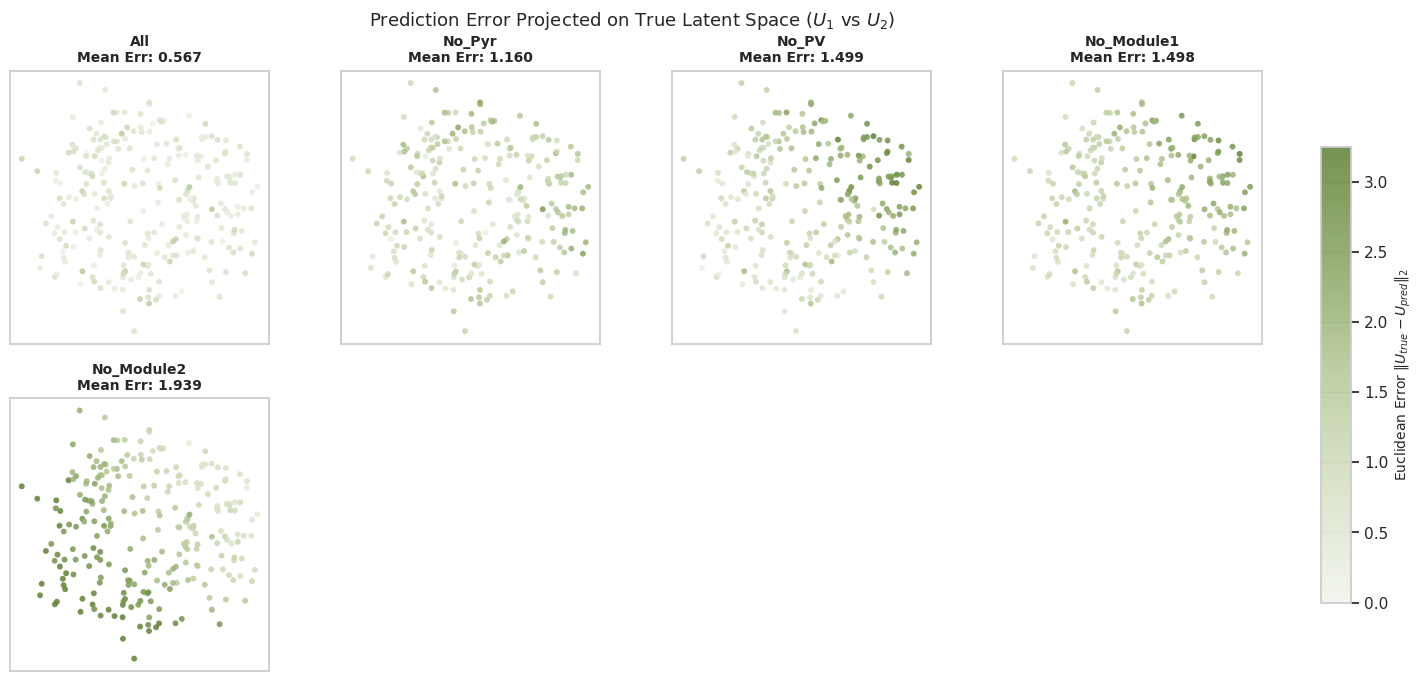

In [34]:
# ==========================================================
# Manifold Error Maps: Full vs. Ablated Models
# ==========================================================
# Compute Euclidean error per sample for each ablation condition
condition_errors = {}
for cond_name, Y_pred in ablation_preds.items():
    condition_errors[cond_name] = np.linalg.norm(U_test_raw - Y_pred, axis=1)

# Set a shared color dynamic range across all conditions for comparison
all_errors = np.concatenate(list(condition_errors.values()))
vmin_err, vmax_err = 0.0, np.percentile(all_errors, 98)

# Custom error ramp matching the GAMoE figures
custom_error_cmap = LinearSegmentedColormap.from_list(
    "custom_error_ramp",
    ["#f1f4ec", "#d6e0c4", "#b5c796", "#86a25f", "#5f7f34"],
    N=256
)

n_conditions = len(condition_errors)
n_cols = 4
n_rows = math.ceil(n_conditions / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows))
axes = np.array(axes).ravel()

last_scatter = None
for idx, (cond_name, err_vec) in enumerate(condition_errors.items()):
    ax = axes[idx]
    
    last_scatter = ax.scatter(
        U_test_raw[:, 0],
        U_test_raw[:, 1],
        c=np.clip(err_vec, vmin_err, vmax_err),
        cmap=custom_error_cmap,
        s=18,
        alpha=0.85,
        vmin=vmin_err,
        vmax=vmax_err,
        linewidths=0
    )
    
    ax.set_title(f"{cond_name}\nMean Err: {err_vec.mean():.3f}", fontsize=10, fontweight="bold")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

# Hide any empty subplot axes
for j in range(n_conditions, len(axes)):
    axes[j].axis("off")

# Global colorbar on the right side
fig.subplots_adjust(right=0.88, top=0.90)
cbar_ax = fig.add_axes([0.91, 0.20, 0.018, 0.60])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_label("Euclidean Error $\\Vert U_{true} - U_{pred} \\Vert_2$", fontsize=10)

fig.suptitle("Prediction Error Projected on True Latent Space ($U_1$ vs $U_2$)", fontsize=13, y=0.98)
plt.show()